# Day 54 - Image Classification Basics

In this notebook we explore the fundamentals of image classification using the MNIST dataset.

Steps covered:

1. Load MNIST dataset
2. Visualize images
3. Understand image structure
4. Normalize pixel values
5. Make predictions using CNN

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os


In [36]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [37]:
print("Training images shape:", X_train.shape)
print("Test images shape:", X_test.shape)

Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


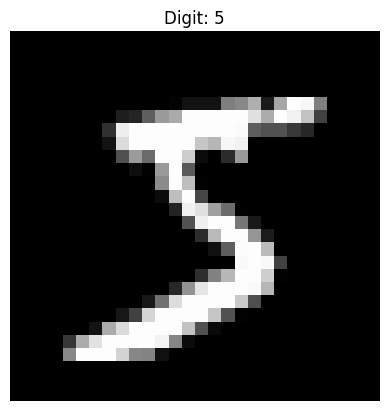

In [38]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

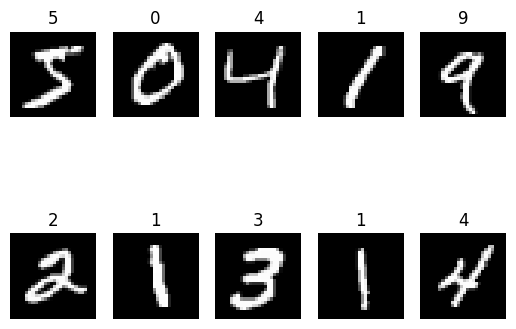

In [39]:
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

In [40]:
print("First image pixel values:\n", X_train[0])
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

First image pixel values:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219

In [41]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [42]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [43]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits
])

In [44]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5


In [ ]:
model.save("model_day54_cnn.keras")

In [ ]:
test_image = X_test[0].reshape(1,28,28,1)  # shape (1,28,28,1)
prediction = model.predict(test_image)
predicted_digit = np.argmax(prediction)
print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Digit: 1


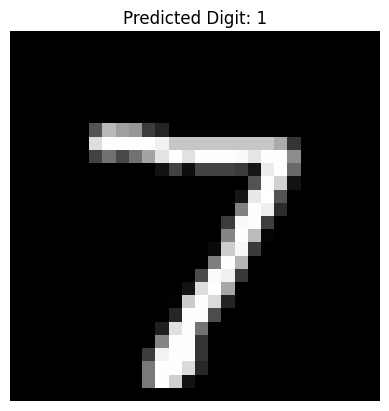

In [ ]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()
plt.imsave("cnn_prediction_example.png", X_test[0].reshape(28,28), cmap="gray")

Image (28x28 pixels)
        ↓
Pixel values (0–255)
        ↓
Normalization (0–1)
        ↓
CNN feature extraction
        ↓
Prediction probabilities
        ↓
Final digit classification